# Landscape Character Result Validation

This notebook validates the results of the landscape character classification for Nigeria. It compares the original (segmented) input data against the final classified landscape character typologies to assess classification accuracy using standard validation metrics.

Key validation aspects include:
- Calculating overall accuracy, producer's accuracy, and user's accuracy,
- Generating confusion matrices to understand misclassification patterns,
- Visualizing validation results through multiple plots, and
- Creating comprehensive summary statistics.

## 1. Configuration and Setup

### 1.1 Configuration Parameters

This section defines key parameters used throughout the validation process. Modify these values to customize the analysis for different scenarios.

In [13]:
# These parameters control various aspects of the validation process

# --- Raster Creation Parameters ---
RASTER_RESOLUTION = 1000  # Resolution in meters (1km)

# --- Validation Sampling Parameters ---
RANDOM_SEED = 42          # Fixed seed for reproducibility
SAMPLE_SIZE = 5000        # Number of random points for validation. Change if otherwise.

# --- Visualization Parameters ---
MAX_CLASSES_SHOW = 40     # Maximum number of classes to show in confusion matrix visualization
                          # (This is for visualization only, all classes are used in calculations)

print("Configuration parameters loaded successfully!")

Configuration parameters loaded successfully!


### 1.2 Import Libraries and Utility Functions

This section imports necessary libraries and defines reusable functions for validation metrics and data processing.

In [14]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, cohen_kappa_score, classification_report
import rasterio
from rasterio.features import rasterize
from rasterio.transform import from_bounds
from scipy.stats import norm, skew
import warnings
warnings.filterwarnings('ignore')

# Set consistent plotting style
plt.style.use('default')
sns.set_palette("husl")

# Define utility functions for reuse

def create_landscape_code(row):
    """Create standardized landscape code from attributes"""
    return f"C{int(row['Climate'])}G{int(row['Geology'])}E{int(row['Elevation'])}L{int(row['Landcover'])}"

def extract_raster_values(x_coords, y_coords, raster_array, transform):
    """Extract values from a raster array at given x,y coordinates"""
    values = []
    for x, y in zip(x_coords, y_coords):
        col = int((x - transform.c) / transform.a)
        row = int((y - transform.f) / transform.e)
        
        if (0 <= row < raster_array.shape[0] and 0 <= col < raster_array.shape[1]):
            values.append(raster_array[row, col])
        else:
            values.append(-9999)
    return values

def calculate_class_metrics(validation_data, class_int, int_to_code):
    """Calculate accuracy metrics for a specific class"""
    class_code = int_to_code[class_int]
    
    # Reference data (for Producer's accuracy)
    ref_mask = validation_data['reference_int'] == class_int
    ref_total = ref_mask.sum()
    
    # Final data (for User's accuracy) 
    final_mask = validation_data['final_int'] == class_int
    final_total = final_mask.sum()
    
    # Correctly classified
    correct = ((validation_data['reference_int'] == class_int) & 
               (validation_data['final_int'] == class_int)).sum()
    
    # Calculate accuracies
    producers_acc = (correct / ref_total * 100) if ref_total > 0 else 0
    users_acc = (correct / final_total * 100) if final_total > 0 else 0
    
    # Calculate errors
    errors_omission = ((ref_total - correct) / ref_total * 100) if ref_total > 0 else 0
    errors_commission = ((final_total - correct) / final_total * 100) if final_total > 0 else 0
    
    return {
        'class_code': class_code,
        'class_int': class_int,
        'producers_acc': producers_acc,
        'users_acc': users_acc,
        'ref_total': ref_total,
        'final_total': final_total,
        'correct': correct,
        'errors_omission': errors_omission,
        'errors_commission': errors_commission
    }

print("Libraries and utility functions loaded successfully!")

Libraries and utility functions loaded successfully!


### 1.3 Load and Prepare Data

This section loads the two primary datasets needed for validation:

1. **Raw landscape data (CSV)**: Contains the initial landscape character data with attributes for Climate, Geology, Elevation, and Landcover
2. **Final landscape polygons (GeoJSON)**: Contains the final classified landscape character units as polygons

These datasets will be compared to evaluate how well the classification process performed in capturing landscape character.

In [15]:
# Load raw landscape data as CSV from cluster_analyses.ipynb - Section 1.4
print("Loading raw landscape data...")
landscape_raw_csv = pd.read_csv('all_output/landscape_data_nigeria.csv')
print(f"Raw CSV shape: {landscape_raw_csv.shape}")
print(f"Raw CSV columns: {landscape_raw_csv.columns.tolist()}")

# Load final landscape polygons also from cluster_analyses.ipynb
print("\nLoading final landscape polygons...")
landscape_polygons = gpd.read_file('all_output/complete_landscape_ch_polygons.geojson')
print(f"Final polygons shape: {landscape_polygons.shape}")
print(f"Final polygons CRS: {landscape_polygons.crs}")

print("\nSample raw data:")
print(landscape_raw_csv.head(3))
print("\nSample final polygons:")
print(landscape_polygons[['complete_code', 'geometry']].head(3))

Loading raw landscape data...
Raw CSV shape: (941272, 7)
Raw CSV columns: ['X', 'Y', 'Elevation', 'Climate', 'Landcover', 'Geology', 'mLST']

Loading final landscape polygons...
Raw CSV shape: (941272, 7)
Raw CSV columns: ['X', 'Y', 'Elevation', 'Climate', 'Landcover', 'Geology', 'mLST']

Loading final landscape polygons...
Final polygons shape: (4591, 18)
Final polygons CRS: GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]

Sample raw data:
        X        Y  Elevation  Climate  Landcover  Geology       mLST
0  615500  1561500          2        4         40        4  38.774647
1  611500  1560500          2        4         30        4  37.428327
2  612500  1560500          2        4         30        4  37.677086

Sample final polygo

## 2. Data Preparation and Alignment

This section prepares the data for validation by:
1. Creating standardized landscape codes
2. Aligning spatial references
3. Creating a unified coding system for comparison

In [16]:
# Create landscape codes using the utility function
landscape_raw_csv['raw_code'] = landscape_raw_csv.apply(create_landscape_code, axis=1)
print("Raw codes created")
print(f"Unique raw codes: {landscape_raw_csv['raw_code'].nunique()}")
print("Sample raw codes:", landscape_raw_csv['raw_code'].head().tolist())

# Create GeoDataFrame from X, Y coordinates
landscape_raw = gpd.GeoDataFrame(
    landscape_raw_csv,
    geometry=gpd.points_from_xy(landscape_raw_csv['X'], landscape_raw_csv['Y']),
    crs='EPSG:4326'
)

# Align CRS with final polygons
landscape_raw = landscape_raw.to_crs(landscape_polygons.crs)
print(f"Raw data CRS aligned: {landscape_raw.crs}")

# Check bounds overlap
raw_bounds = landscape_raw.total_bounds
final_bounds = landscape_polygons.total_bounds
print(f"Raw bounds: {raw_bounds}")
print(f"Final bounds: {final_bounds}")

# Check code formats match
print(f"\nCode format comparison:")
print("Raw codes:", landscape_raw['raw_code'].head(3).tolist())
print("Final codes:", landscape_polygons['complete_code'].head(3).tolist())

Raw codes created
Unique raw codes: 337
Sample raw codes: ['C4G4E2L40', 'C4G4E2L30', 'C4G4E2L30', 'C4G4E2L30', 'C4G4E2L30']
Raw data CRS aligned: GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]
Raw bounds: [ 298500.  477500. 1633500. 1561500.]
Final bounds: [ 298500.  477500. 1633500. 1561500.]

Code format comparison:
Raw codes: ['C4G4E2L40', 'C4G4E2L30', 'C4G4E2L30']
Final codes: ['C4G4E2L30', 'C4G4E2L60', 'C4G4E2L30']
Raw data CRS aligned: GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","432

In [17]:
# Create unified code mapping for consistent comparison

# Get all unique landscape codes from both datasets
all_landscape_codes = sorted(set(landscape_raw['raw_code'].unique()) | 
                           set(landscape_polygons['complete_code'].unique()))

print(f"Total unique landscape codes: {len(all_landscape_codes)}")
print(f"Raw codes: {landscape_raw['raw_code'].nunique()}")
print(f"Final codes: {landscape_polygons['complete_code'].nunique()}")

# Create unified mapping - SAME CODE GETS SAME INTEGER
unified_code_to_int = {code: idx for idx, code in enumerate(all_landscape_codes)}
int_to_code = {v: k for k, v in unified_code_to_int.items()}  # For reverse lookup

# Apply unified mapping to both datasets
landscape_raw['unified_int'] = landscape_raw['raw_code'].map(unified_code_to_int)
landscape_polygons['unified_int'] = landscape_polygons['complete_code'].map(unified_code_to_int)

print("Unified integer mapping applied")

# Verify same codes get same integers
test_codes = ['C4G4E2L40', 'C4G4E2L30', 'C2G4E1L10']
for code in test_codes:
    if code in unified_code_to_int:
        print(f"{code} -> {unified_code_to_int[code]} (both datasets)")

print(f"Unified mapping range: 0 to {len(all_landscape_codes)-1}")

Total unique landscape codes: 337
Raw codes: 337
Final codes: 131
Unified integer mapping applied
C4G4E2L40 -> 206 (both datasets)
C4G4E2L30 -> 205 (both datasets)
C2G4E1L10 -> 21 (both datasets)
Unified mapping range: 0 to 336


## 3. Rasterization and Random Sampling

This section:
1. Creates raster surfaces from both vector datasets
2. Generates random points for validation
3. Extracts values from both rasters at those points
4. Creates a clean validation dataset

In [18]:
# Create raster surfaces for both datasets using consistent parameters

# Use final polygon bounds
bounds = landscape_polygons.total_bounds
resolution = RASTER_RESOLUTION  # Use configuration parameter
width = int((bounds[2] - bounds[0]) / resolution)
height = int((bounds[3] - bounds[1]) / resolution)
transform = from_bounds(bounds[0], bounds[1], bounds[2], bounds[3], width, height)

print(f"Raster dimensions: {width} x {height}")
print(f"Resolution: {resolution}m")

# Create reference raster from points
ref_shapes = [(geom, unified_int) for geom, unified_int in 
              zip(landscape_raw.geometry, landscape_raw['unified_int'])
              if not pd.isna(unified_int)]

reference_raster = rasterize(
    ref_shapes,
    out_shape=(height, width),
    transform=transform,
    fill=-9999,  # NoData
    dtype='int32'
)

# Create final raster from polygons
final_shapes = [(geom, unified_int) for geom, unified_int in 
                zip(landscape_polygons.geometry, landscape_polygons['unified_int'])
                if not pd.isna(unified_int)]

final_raster = rasterize(
    final_shapes,
    out_shape=(height, width),
    transform=transform,
    fill=-9999,  # NoData
    dtype='int32'
)

print(f"Reference raster - min: {reference_raster.min()}, max: {reference_raster.max()}")
print(f"Final raster - min: {final_raster.min()}, max: {final_raster.max()}")
print(f"Reference NoData: {np.sum(reference_raster == -9999)} pixels")
print(f"Final NoData: {np.sum(final_raster == -9999)} pixels")

Raster dimensions: 1335 x 1084
Resolution: 1000m

Resolution: 1000m
Reference raster - min: -9999, max: 336
Final raster - min: -9999, max: 327
Reference NoData: 505878 pixels
Final NoData: 507931 pixels
Reference raster - min: -9999, max: 336
Final raster - min: -9999, max: 327
Reference NoData: 505878 pixels
Final NoData: 507931 pixels


In [19]:
# Generate random points and create validation dataset

# Set random seed from configuration
np.random.seed(RANDOM_SEED)

# Generate random points using configured sample size
n_points = SAMPLE_SIZE
random_x = np.random.uniform(bounds[0], bounds[2], n_points)
random_y = np.random.uniform(bounds[1], bounds[3], n_points)

print(f"Generated {n_points} random points using seed {RANDOM_SEED}")

# Extract values from both rasters using the utility function
reference_values = extract_raster_values(random_x, random_y, reference_raster, transform)
final_values = extract_raster_values(random_x, random_y, final_raster, transform)

# Create validation dataset and remove NoData
validation_df = pd.DataFrame({
    'x': random_x,
    'y': random_y,
    'reference_int': reference_values,
    'final_int': final_values
})

# Remove NoData points
valid_mask = (validation_df['reference_int'] != -9999) & (validation_df['final_int'] != -9999)
validation_clean = validation_df[valid_mask].copy()

# Add landscape codes for readability
validation_clean['reference_code'] = validation_clean['reference_int'].map(int_to_code)
validation_clean['final_code'] = validation_clean['final_int'].map(int_to_code)

print(f"Valid points for validation: {len(validation_clean)}")
print(f"Points removed (NoData): {len(validation_df) - len(validation_clean)}")
print("\nSample validation data:")
print(validation_clean[['reference_code', 'final_code']].head())

Generated 5000 random points using seed 42
Valid points for validation: 3243
Points removed (NoData): 1757

Sample validation data:
  reference_code final_code
0      C3G4E2L30  C3G4E2L10
2      C4G4E2L30  C4G4E2L40
3      C3G3E2L40  C3G4E2L40
4      C4G4E2L40  C4G4E2L40
7      C4G4E2L30  C4G4E2L30


Creating validation points map...


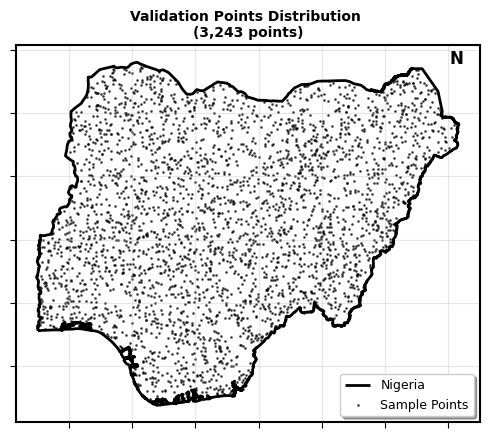

Distribution of Valid Random Points - Saved


In [50]:
# Plot validation points over Nigeria boundary
print("Creating validation points map...")

# Load Nigeria boundary
nigeria_boundary = gpd.read_file('all_input_dataset/nig_bounds.geojson')

# Ensure CRS alignment
if nigeria_boundary.crs != landscape_polygons.crs:
    nigeria_boundary = nigeria_boundary.to_crs(landscape_polygons.crs)

# Create the plot - reduced size for half A5 sheet
fig, ax = plt.subplots(figsize=(5, 5))

# Plot Nigeria boundary with thick black lines first
nigeria_boundary.boundary.plot(ax=ax, color='black', linewidth=2, aspect=None, label='Nigeria')

# Plot validation points using matplotlib directly - black and larger
ax.scatter(validation_clean['x'], validation_clean['y'], 
           c='black', s=1, alpha=0.6, label='Sample Points')

ax.set_title(f'Validation Points Distribution \n({len(validation_clean):,} points)', 
             fontsize=10, fontweight='bold')

# Remove axis labels but keep grid
ax.set_xlabel('')
ax.set_ylabel('')
ax.grid(True, alpha=0.3)

# Set equal aspect ratio after plotting
ax.set_aspect('equal', adjustable='box')

# Remove tick labels but keep ticks for reference
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.tick_params(axis='both', which='major', length=4)

# Add neat bounding box
for spine in ax.spines.values():
    spine.set_linewidth(1.5)
    spine.set_color('black')

# Add simple legend
ax.legend(loc='lower right', fontsize=9, frameon=True, fancybox=True, shadow=True)

# Add North arrow
ax.annotate('N', xy=(0.95, 0.95), xycoords='axes fraction', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('all_output/validation_points_distribution.png', dpi=300, bbox_inches='tight')
plt.savefig('all_output/validation_points_distribution.pdf', bbox_inches='tight')
plt.show()

print("Distribution of Valid Random Points - Saved")

## 4. Validation Metrics Calculation

This section calculates all the key validation metrics in one place:
1. Overall accuracy and Kappa statistic
2. Per-class Producer's and User's accuracies
3. Confusion matrix
4. Additional metrics like F1-score and errors of omission/commission

In [20]:
# Extract arrays for validation
reference_array = validation_clean['reference_int'].values
final_array = validation_clean['final_int'].values
unique_classes = sorted(set(reference_array) | set(final_array))

# Calculate overall metrics
overall_accuracy = accuracy_score(reference_array, final_array)
kappa = cohen_kappa_score(reference_array, final_array)
correctly_classified = sum((reference_array == final_array).astype(int))
total_validation_points = len(validation_clean)
reference_landscape_types = validation_clean['reference_int'].nunique()
final_landscape_types = validation_clean['final_int'].nunique()

# Create confusion matrix - ONCE
conf_matrix = confusion_matrix(reference_array, final_array, labels=unique_classes)

# Calculate per-class metrics using the utility function
class_metrics = []
for class_int in sorted(validation_clean['reference_int'].unique()):
    # Skip classes with too few samples
    if len(validation_clean[validation_clean['reference_int'] == class_int]) < 5:
        continue
        
    metrics = calculate_class_metrics(validation_clean, class_int, int_to_code)
    class_metrics.append(metrics)

# Create comprehensive metrics DataFrame for reuse in visualizations
metrics_df = pd.DataFrame(class_metrics)

# Calculate averages
avg_producers_acc = metrics_df['producers_acc'].mean()
avg_users_acc = metrics_df['users_acc'].mean()

# Additional classification report metrics
class_report_dict = classification_report(
    validation_clean['reference_int'], 
    validation_clean['final_int'], 
    output_dict=True,
    zero_division=0
)

# Merge sklearn report metrics into our metrics dataframe
for class_int in metrics_df['class_int']:
    if str(class_int) in class_report_dict:
        idx = metrics_df.index[metrics_df['class_int'] == class_int].tolist()[0]
        metrics_df.loc[idx, 'precision'] = class_report_dict[str(class_int)]['precision'] * 100
        metrics_df.loc[idx, 'recall'] = class_report_dict[str(class_int)]['recall'] * 100
        metrics_df.loc[idx, 'f1_score'] = class_report_dict[str(class_int)]['f1-score'] * 100
        metrics_df.loc[idx, 'support'] = class_report_dict[str(class_int)]['support']

# Display summary statistics
print(f"=== VALIDATION RESULTS ===")
print(f"Overall Accuracy: {overall_accuracy:.4f} ({overall_accuracy*100:.2f}%)")
print(f"Cohen's Kappa: {kappa:.4f}")
print(f"Average Producer's Accuracy: {avg_producers_acc:.2f}%")
print(f"Average User's Accuracy: {avg_users_acc:.2f}%")
print(f"Validation points: {total_validation_points:,}")
print(f"Correctly classified points: {correctly_classified:,}")
print(f"Number of landscape classes: {len(unique_classes)}")

# Show class distribution
ref_dist = validation_clean['reference_code'].value_counts()
final_dist = validation_clean['final_code'].value_counts()

print(f"\nTop 5 reference landscape types:")
print(ref_dist.head())
print(f"\nTop 5 final landscape types:")
print(final_dist.head())

# Save base validation results
validation_clean.to_csv('all_output/validation_data_final.csv', index=False)

=== VALIDATION RESULTS ===
Overall Accuracy: 0.7441 (74.41%)
Cohen's Kappa: 0.7342
Average Producer's Accuracy: 60.40%
Average User's Accuracy: 63.08%
Validation points: 3,243
Correctly classified points: 2,413
Number of landscape classes: 153

Top 5 reference landscape types:
reference_code
C4G4E2L40    362
C4G4E2L30    202
C2G4E1L10    194
C3G4E2L40    143
C5G4E2L30    122
Name: count, dtype: int64

Top 5 final landscape types:
final_code
C4G4E2L40    398
C2G4E1L10    217
C4G4E2L30    179
C3G4E2L40    166
C5G4E2L30    129
Name: count, dtype: int64


## 5. Visualization of Results

This section creates visualizations based on the metrics calculated in the previous section.

### 5.1 Confusion Matrix Visualization

Showing confusion matrix for top 40 most common classes...


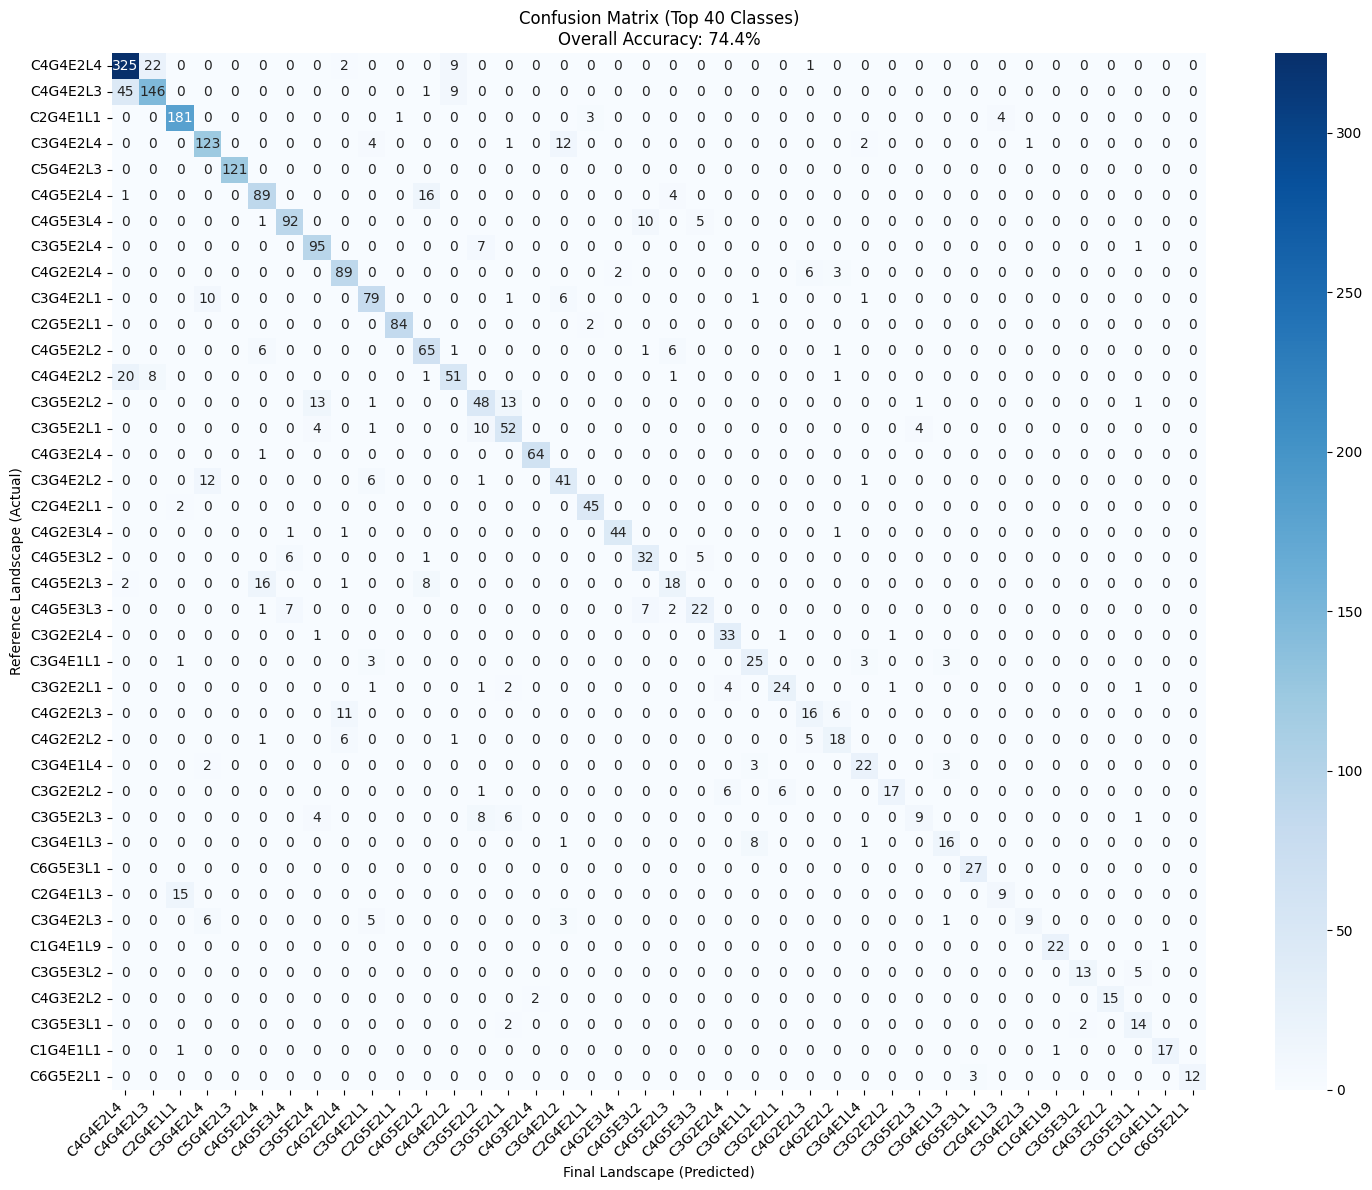

In [21]:
# Create confusion matrix visualization

# For visualization, show top classes only (matrix too large otherwise)
max_classes_show = MAX_CLASSES_SHOW  # From configuration
top_ref_classes = validation_clean['reference_int'].value_counts().head(max_classes_show).index.tolist()

if len(unique_classes) > max_classes_show:
    print(f"Showing confusion matrix for top {max_classes_show} most common classes...")
    
    # Filter to top classes
    mask = validation_clean['reference_int'].isin(top_ref_classes) & validation_clean['final_int'].isin(top_ref_classes)
    validation_subset = validation_clean[mask]
    
    conf_matrix_subset = confusion_matrix(
        validation_subset['reference_int'].values,
        validation_subset['final_int'].values,
        labels=top_ref_classes
    )
    
    # Create readable labels
    class_labels = [int_to_code[cls][:8] for cls in top_ref_classes]  # Truncate for display
    
    plt.figure(figsize=(15, 12))
    sns.heatmap(conf_matrix_subset, 
                annot=True, 
                fmt='d', 
                cmap='Blues',
                xticklabels=class_labels,
                yticklabels=class_labels
    )
    plt.title(f'Confusion Matrix (Top {len(top_ref_classes)} Classes)\nOverall Accuracy: {overall_accuracy:.1%}')
    plt.xlabel('Final Landscape (Predicted)')
    plt.ylabel('Reference Landscape (Actual)')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    
else:
    # Full matrix if manageable
    plt.figure(figsize=(15, 12))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Full Confusion Matrix\nOverall Accuracy: {overall_accuracy:.1%}')
    plt.xlabel('Final Landscape')
    plt.ylabel('Reference Landscape')

# Save plots
plt.savefig('all_output/confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.savefig('all_output/confusion_matrix.pdf', bbox_inches='tight')
plt.show()

# Save confusion matrix as CSV
conf_df = pd.DataFrame(conf_matrix,
                       index=[f'Ref_{cls}' for cls in unique_classes],
                       columns=[f'Final_{cls}' for cls in unique_classes])
conf_df.to_csv('all_output/confusion_matrix.csv')

### 5.2 Scatter Plot - User's vs Producer's Accuracy

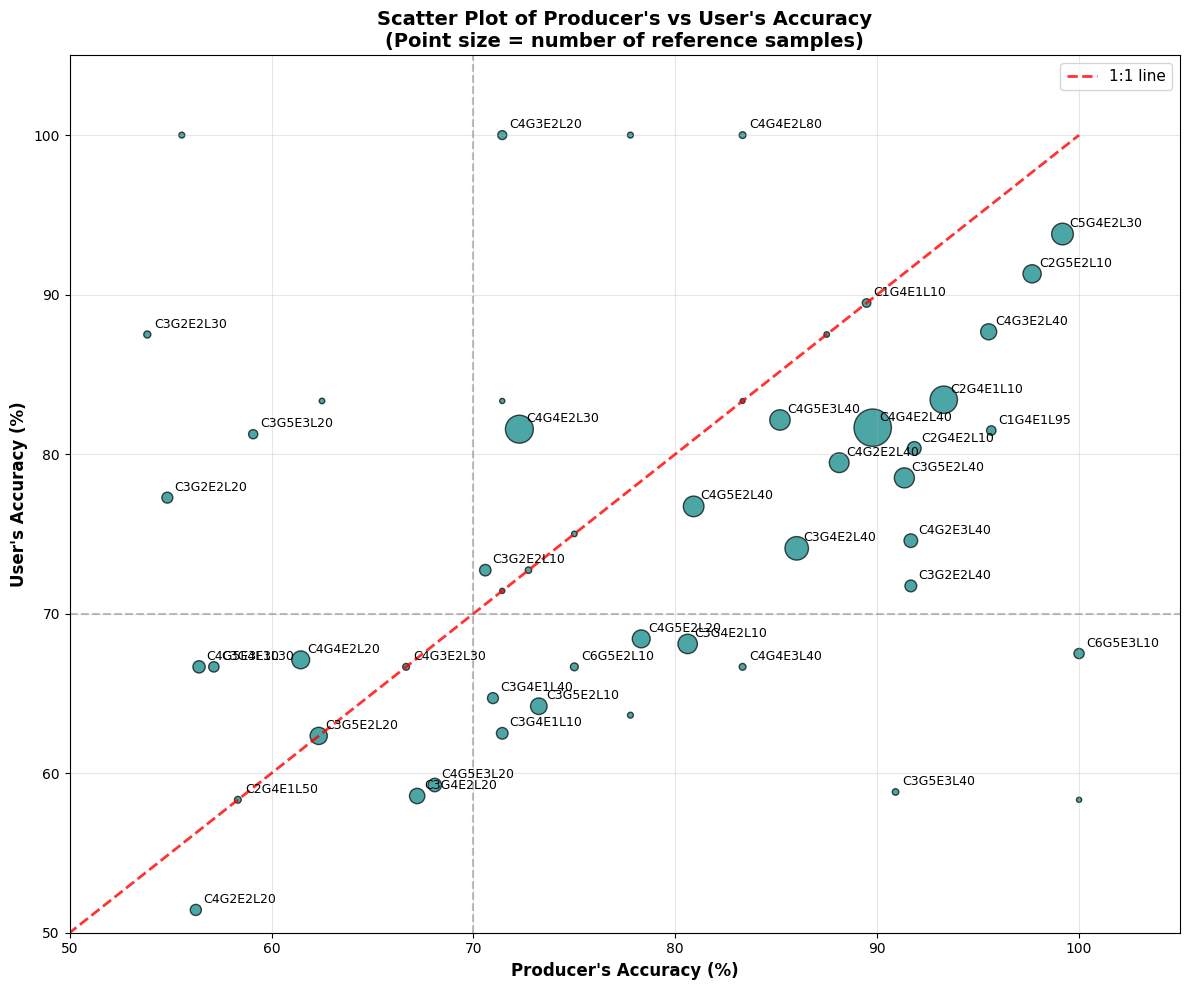

In [22]:
# Create scatter plot using the metrics DataFrame

fig, ax = plt.subplots(figsize=(12, 10))

scatter = ax.scatter(metrics_df['producers_acc'], metrics_df['users_acc'], 
                    s=metrics_df['ref_total']*2, alpha=0.7, c='teal', edgecolors='black')

# Add 1:1 line
ax.plot([0, 100], [0, 100], 'r--', linewidth=2, alpha=0.8, label='1:1 line')

# Add threshold lines
ax.axhline(y=70, color='gray', linestyle='--', alpha=0.5)
ax.axvline(x=70, color='gray', linestyle='--', alpha=0.5)

# Label points for top classes
for idx, row in metrics_df.nlargest(50, 'ref_total').iterrows():
    ax.annotate(row['class_code'], 
                (row['producers_acc'], row['users_acc']),
                xytext=(5, 5), textcoords='offset points',
                fontsize=9, ha='left')

ax.set_xlabel("Producer's Accuracy (%)", fontsize=12, fontweight='bold')
ax.set_ylabel("User's Accuracy (%)", fontsize=12, fontweight='bold')
ax.set_title("Scatter Plot of Producer's vs User's Accuracy\n(Point size = number of reference samples)", 
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim(50, 105)
ax.set_ylim(50, 105)

plt.tight_layout()
plt.savefig('all_output/accuracy_scatter_plot.png', dpi=300, bbox_inches='tight')
plt.savefig('all_output/accuracy_scatter_plot.pdf', bbox_inches='tight')
plt.show()

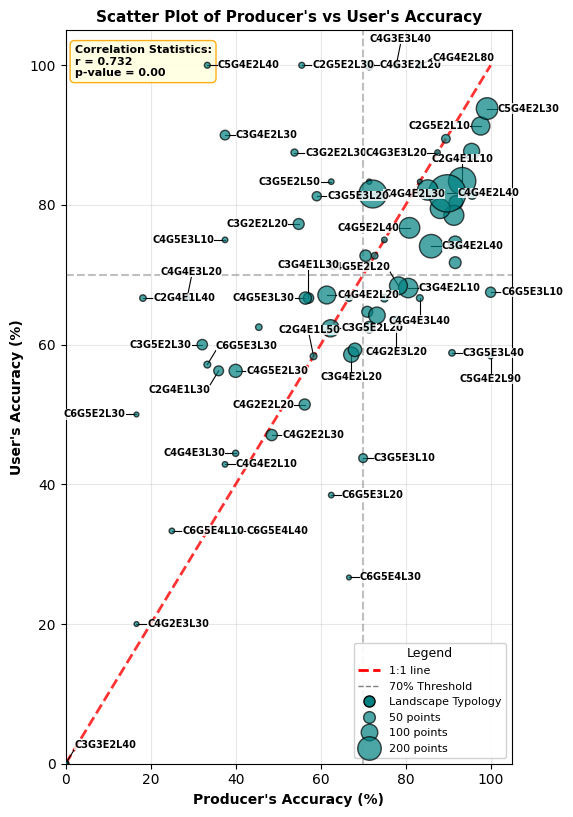

Correlation between Producer's and User's Accuracy:
Pearson's r: 0.732
P-value: 0.0000
Interpretation: Significant correlation
Labeling statistics: 50 points labeled with connecting lines, 28 points skipped due to potential overlaps


In [69]:
# Create scatter plot using the metrics DataFrame with more visible black connecting lines

import scipy.stats as stats
from matplotlib.lines import Line2D
import numpy as np
import random

# Set random seed for reproducible results
random.seed(42)

# A5 paper size in inches (148 × 210 mm): 5.83 × 8.27 inches
fig, ax = plt.subplots(figsize=(5.83, 8.27))

# Calculate correlation statistics
correlation_coefficient = np.corrcoef(metrics_df['producers_acc'], metrics_df['users_acc'])[0, 1]
r_squared = correlation_coefficient ** 2
correlation_stat, p_value = stats.pearsonr(metrics_df['producers_acc'], metrics_df['users_acc'])

# Define the point color for landscape typology
landscape_color = 'teal'

# Prepare all candidate points for labeling
all_points = []
for idx, row in metrics_df.iterrows():
    x, y = row['producers_acc'], row['users_acc']
    # Include all points within plot area that should be labeled
    if 0 <= x <= 105 and 0 <= y <= 105:
        all_points.append({
            'x': x, 
            'y': y, 
            'code': row['class_code'], 
            'ref_total': row['ref_total'],
            'idx': idx
        })

# Sort points by multiple criteria:
# 1. First sort by reference total (larger points get priority)
# 2. Then further prioritize points in less crowded areas
for point in all_points:
    # Calculate a crowding score - lower is better (less crowded)
    crowd_score = 0
    x, y = point['x'], point['y']
    
    for other in all_points:
        if other['idx'] == point['idx']:
            continue
        
        dist_x = abs(other['x'] - x)
        dist_y = abs(other['y'] - y)
        dist = np.sqrt(dist_x**2 + dist_y**2)
        
        if dist < 10:  # Points are close
            crowd_score += (10 - dist) * (other['ref_total'] / 50)
    
    point['crowd_score'] = crowd_score

# First sort by ref_total (descending), then by crowd_score (ascending)
all_points.sort(key=lambda p: (-p['ref_total'], p['crowd_score']))

# Different positions to try around each point
positions_to_try = [
    # Cardinal directions first (horizontal and vertical)
    (2.5, 0, 'left', 'center'),    # right
    (-2.5, 0, 'right', 'center'),  # left
    (0, 2.5, 'center', 'bottom'),  # above
    (0, -2.5, 'center', 'top'),    # below
    
    # Then try diagonal positions
    (2, 2, 'left', 'bottom'),      # top-right
    (-2, 2, 'right', 'bottom'),    # top-left
    (2, -2, 'left', 'top'),        # bottom-right
    (-2, -2, 'right', 'top'),      # bottom-left
    
    # Try other angles with different distances
    (3, 1, 'left', 'center'),      # right-slight-up
    (3, -1, 'left', 'center'),     # right-slight-down
    (-3, 1, 'right', 'center'),    # left-slight-up
    (-3, -1, 'right', 'center'),   # left-slight-down
    (1, 3, 'center', 'bottom'),    # above-slight-right
    (-1, 3, 'center', 'bottom'),   # above-slight-left
    (1, -3, 'center', 'top'),      # below-slight-right
    (-1, -3, 'center', 'top'),     # below-slight-left
    
    # Further distances for very crowded areas
    (4, 0, 'left', 'center'),      # further right
    (-4, 0, 'right', 'center'),    # further left
    (0, 4, 'center', 'bottom'),    # further above
    (0, -4, 'center', 'top'),      # further below
]

# First, draw the connecting lines and store positions for labels
connection_lines = []
label_positions = []
label_boxes = []
labeled_points = []
skipped_points = []

# Define overlap check function
def check_overlap(new_box, existing_boxes, buffer=2.0):
    """Check if a label box would overlap with any existing label boxes"""
    x1, y1, x2, y2 = new_box
    
    for box in existing_boxes:
        box_x1, box_y1, box_x2, box_y2 = box
        # Check if boxes overlap with buffer
        if not (x2 + buffer < box_x1 or x1 - buffer > box_x2 or 
                y2 + buffer < box_y1 or y1 - buffer > box_y2):
            return True
    
    return False

# First pass to determine label positions using same algorithm as before
for point in all_points:
    x, y = point['x'], point['y']
    label_text = point['code']
    ref_total = point['ref_total']
    
    # Calculate label dimensions - adjust based on text length
    label_width = len(label_text) * 1.2  # in data coordinates
    label_height = 2.0  # in data coordinates
    
    # Try each position around the point
    label_placed = False
    
    for dx, dy, halign, valign in positions_to_try:
        # Calculate label position
        label_x = x + dx
        label_y = y + dy
        
        # Ensure label stays within plot boundaries (with margin)
        if label_x < 1 or label_x > 104 or label_y < 1 or label_y > 104:
            continue
        
        # Calculate label box coordinates based on alignment
        if halign == 'left':
            box_x1 = label_x
            box_x2 = label_x + label_width
        elif halign == 'right':
            box_x1 = label_x - label_width
            box_x2 = label_x
        else:  # center
            box_x1 = label_x - label_width / 2
            box_x2 = label_x + label_width / 2
            
        if valign == 'top':
            box_y1 = label_y - label_height
            box_y2 = label_y
        elif valign == 'bottom':
            box_y1 = label_y
            box_y2 = label_y + label_height
        else:  # center
            box_y1 = label_y - label_height / 2
            box_y2 = label_y + label_height / 2
        
        label_box = (box_x1, box_y1, box_x2, box_y2)
        
        # Check with a larger buffer for more important points
        buffer = 2.0
        if ref_total < 20:  # Less important points can be packed tighter
            buffer = 1.5
            
        # Strict overlap check
        if not check_overlap(label_box, label_boxes, buffer=buffer):
            # Store label information
            label_positions.append({
                'point_x': x,
                'point_y': y,
                'label_x': label_x,
                'label_y': label_y,
                'text': label_text,
                'halign': halign,
                'valign': valign,
                'ref_total': ref_total,
                'box': label_box
            })
            
            # Track this label's box to avoid future overlaps
            label_boxes.append(label_box)
            labeled_points.append(point['idx'])
            connection_lines.append((x, y, label_x, label_y))
            label_placed = True
            break
    
    # If no suitable position found, skip this point
    if not label_placed:
        skipped_points.append(point['idx'])

# Now draw the actual plot
# Set axis limits
ax.set_xlim(0, 105)
ax.set_ylim(0, 105)

# Add 1:1 line and threshold lines first (below points and lines)
ax.plot([0, 100], [0, 100], 'r--', linewidth=2, alpha=0.8, label='1:1 line')
ax.axhline(y=70, color='gray', linestyle='--', alpha=0.5, label='70% Threshold')
ax.axvline(x=70, color='gray', linestyle='--', alpha=0.5)

# Draw the connecting lines BEFORE the points for proper layering
for x, y, label_x, label_y in connection_lines:
    # Draw the connecting line as solid black line
    ax.plot([x, label_x], [y, label_y], 'k-', linewidth=0.8, zorder=5)

# Now draw the scatter plot on top of the lines
scatter = ax.scatter(metrics_df['producers_acc'], metrics_df['users_acc'], 
                    s=metrics_df['ref_total']*2, alpha=0.7, c=landscape_color, 
                    edgecolors='black', zorder=10)

# Finally add the labels on top of everything
for label_info in label_positions:
    ax.text(label_info['label_x'], label_info['label_y'], label_info['text'],
           ha=label_info['halign'], va=label_info['valign'], fontsize=7, fontweight='bold',
           bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=0.1),
           zorder=15)

# Add axes labels and title
ax.set_xlabel("Producer's Accuracy (%)", fontsize=10, fontweight='bold')
ax.set_ylabel("User's Accuracy (%)", fontsize=10, fontweight='bold')
ax.set_title("Scatter Plot of Producer's vs User's Accuracy", 
             fontsize=11, fontweight='bold')
ax.grid(True, alpha=0.3)

# Create custom legend elements
legend_elements = [
    Line2D([0], [0], color='r', linestyle='--', lw=2, label='1:1 line'),
    Line2D([0], [0], color='gray', linestyle='--', lw=1, label='70% Threshold'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=landscape_color, 
           markersize=8, label='Landscape Typology', markeredgecolor='black')
]

# Create size legend elements
sample_sizes = [50, 100, 200]
for size in sample_sizes:
    legend_elements.append(
        Line2D([0], [0], marker='o', color='w', markerfacecolor=landscape_color,
               markersize=np.sqrt(size*2/np.pi)*1.5, label=f'{size} points', 
               markeredgecolor='black', alpha=0.7)
    )

# Add the legend with both line and marker elements
ax.legend(handles=legend_elements, loc='lower right', fontsize=8, 
          title='Legend', title_fontsize=9, framealpha=0.9)

# Add correlation statistics text box
correlation_text = f"""Correlation Statistics:
r = {correlation_coefficient:.3f}
p-value = {p_value:.2f}"""

ax.text(0.02, 0.98, correlation_text, transform=ax.transAxes, fontsize=8,
        verticalalignment='top', fontweight='bold',
        bbox=dict(boxstyle="round,pad=0.4", facecolor="lightyellow", alpha=0.9, 
                 edgecolor='orange', linewidth=1))

plt.tight_layout()
plt.savefig('all_output/accuracy_scatter_plot.png', dpi=300, bbox_inches='tight')
plt.savefig('all_output/accuracy_scatter_plot.pdf', bbox_inches='tight')
plt.show()

print(f"Correlation between Producer's and User's Accuracy:")
print(f"Pearson's r: {correlation_coefficient:.3f}")
print(f"P-value: {p_value:.4f}")
print(f"Interpretation: {'Significant' if p_value < 0.05 else 'Not significant'} correlation")
print(f"Labeling statistics: {len(labeled_points)} points labeled with connecting lines, {len(skipped_points)} points skipped due to potential overlaps")

### 5.3 Dashboard Visualization

This visualization combines multiple metrics into a single dashboard:

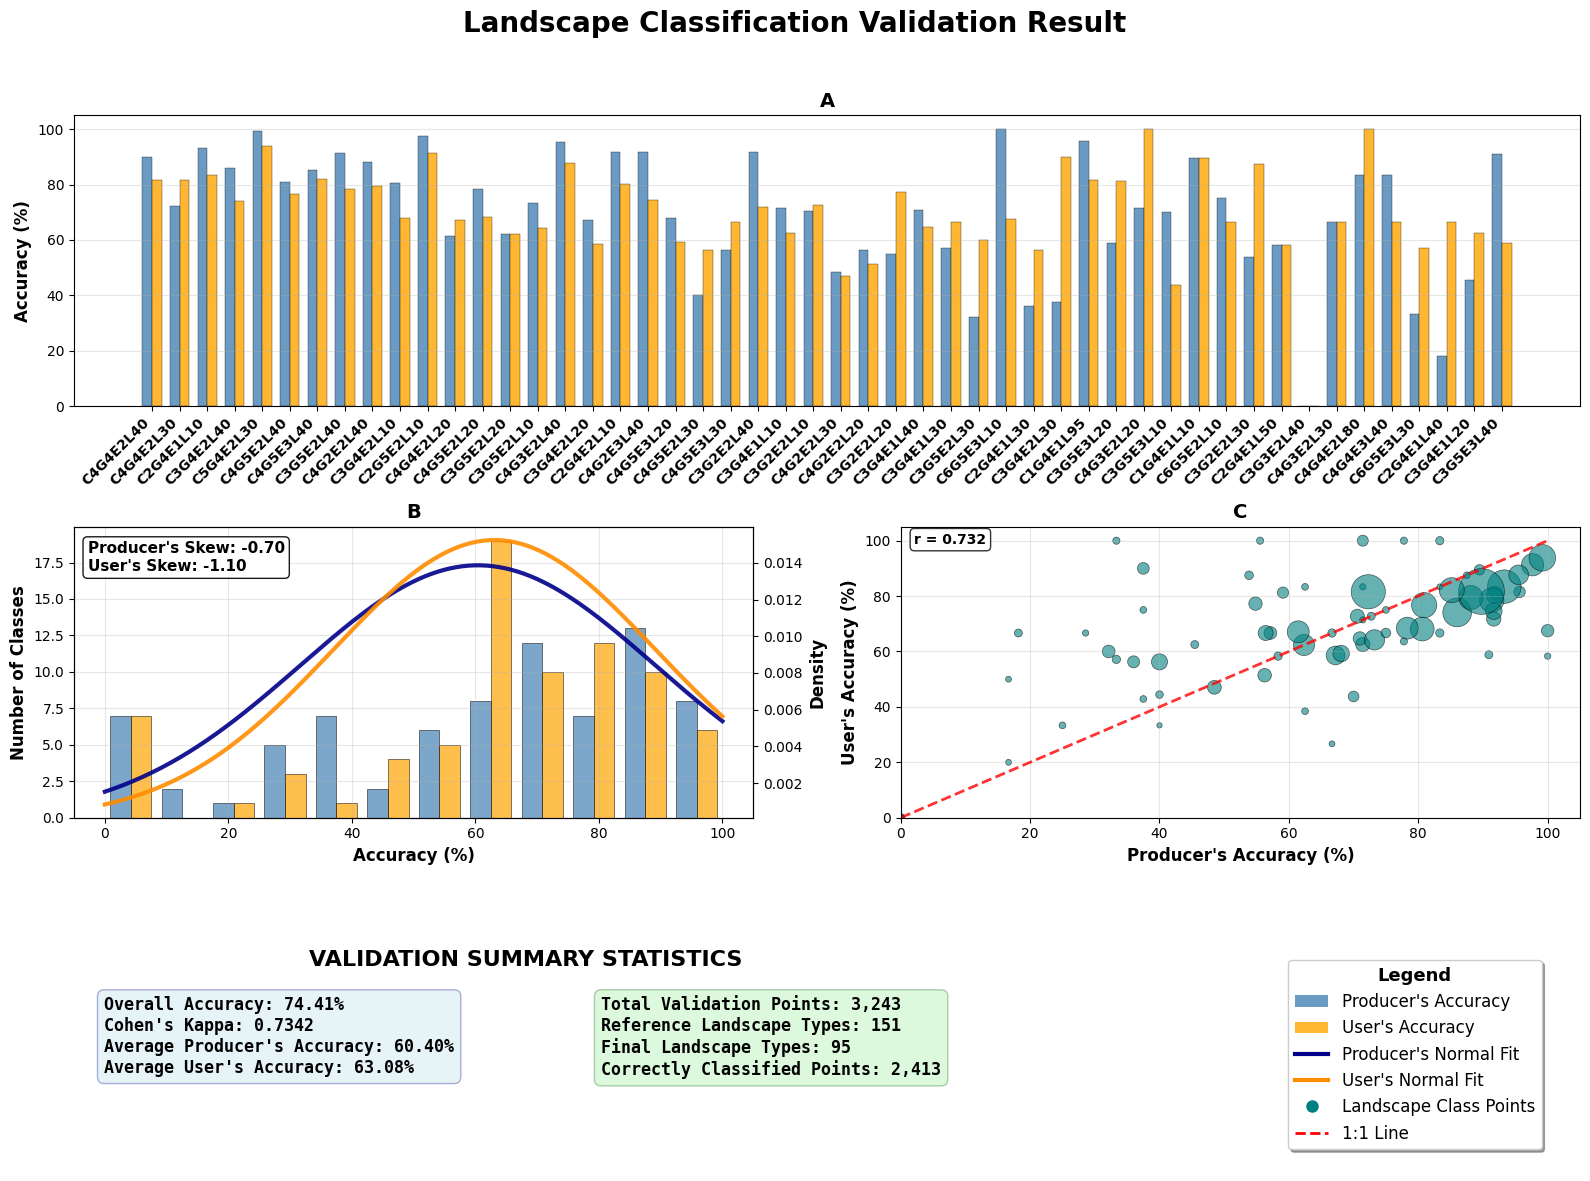

In [70]:
# Create comprehensive dashboard

# Define colors for consistency
producer_color = 'steelblue'
user_color = 'orange'

# Create the dashboard layout
fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(3, 2, height_ratios=[1, 1, 0.8], width_ratios=[1, 1])

# 1. TOP - TOP 50 CLASSES SORTED BY SAMPLE SIZE (spans full width)
ax1 = fig.add_subplot(gs[0, :])

# Sort by sample size (ref_total) and take top 50 - keep this sorting for display
top_50_by_sample = metrics_df.nlargest(50, 'ref_total')

x = np.arange(len(top_50_by_sample))
width = 0.35

bars1 = ax1.bar(x - width/2, top_50_by_sample['producers_acc'], width,
               label="Producer's Accuracy", color=producer_color, alpha=0.8, edgecolor='black', linewidth=0.3)
bars2 = ax1.bar(x + width/2, top_50_by_sample['users_acc'], width,
               label="User's Accuracy", color=user_color, alpha=0.8, edgecolor='black', linewidth=0.3)

ax1.set_xticks(x)
ax1.set_xticklabels(top_50_by_sample['class_code'], rotation=45, ha='right', fontsize=10, fontweight='bold')
ax1.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
ax1.set_title('A', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')
ax1.set_ylim(0, 105)

# 2. MIDDLE-LEFT - ACCURACY DISTRIBUTIONS (side-by-side bars, not stacked)
ax2 = fig.add_subplot(gs[1, 0])

# Create side-by-side histograms
n_bins = 12

# Get bin edges that work for both datasets
_, bins = np.histogram(np.concatenate([metrics_df['producers_acc'], metrics_df['users_acc']]), bins=n_bins)
bin_width = bins[1] - bins[0]
bar_width = bin_width * 0.4

# Create separate histograms with offset positions
prod_counts, _ = np.histogram(metrics_df['producers_acc'], bins=bins)
user_counts, _ = np.histogram(metrics_df['users_acc'], bins=bins)

bin_centers = (bins[:-1] + bins[1:]) / 2

ax2.bar(bin_centers - bar_width/2, prod_counts, width=bar_width, 
        color=producer_color, alpha=0.7, edgecolor='black', linewidth=0.5, 
        label="Producer's Accuracy")
ax2.bar(bin_centers + bar_width/2, user_counts, width=bar_width, 
        color=user_color, alpha=0.7, edgecolor='black', linewidth=0.5,
        label="User's Accuracy")

# Create twin axis for normal curves
ax2_twin = ax2.twinx()

# Fit and plot normal distribution curves
prod_mean, prod_std = metrics_df['producers_acc'].mean(), metrics_df['producers_acc'].std()
user_mean, user_std = metrics_df['users_acc'].mean(), metrics_df['users_acc'].std()

x_norm = np.linspace(0, 100, 200)
ax2_twin.plot(x_norm, norm.pdf(x_norm, prod_mean, prod_std), 
             color='darkblue', linewidth=3, alpha=0.9,
             label="Producer's Normal Fit")
ax2_twin.plot(x_norm, norm.pdf(x_norm, user_mean, user_std), 
             color='darkorange', linewidth=3, alpha=0.9,
             label="User's Normal Fit")

ax2.set_xlabel('Accuracy (%)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Number of Classes', fontsize=12, fontweight='bold')
ax2_twin.set_ylabel('Density', fontsize=12, fontweight='bold')
ax2.set_title('B', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)

# Add skewness information
prod_skew = skew(metrics_df['producers_acc'])
user_skew = skew(metrics_df['users_acc'])
ax2.text(0.02, 0.95, f"Producer's Skew: {prod_skew:.2f}\nUser's Skew: {user_skew:.2f}", 
         transform=ax2.transAxes, fontsize=11, verticalalignment='top', fontweight='bold',
         bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.9, edgecolor='black'))

# 3. MIDDLE-RIGHT - SCATTER PLOT with correlation
ax3 = fig.add_subplot(gs[1, 1])

# Calculate correlation for dashboard
correlation_coeff = np.corrcoef(metrics_df['producers_acc'], metrics_df['users_acc'])[0, 1]
r_sq = correlation_coeff ** 2

scatter = ax3.scatter(metrics_df['producers_acc'], metrics_df['users_acc'],
                     s=metrics_df['ref_total']*3, alpha=0.6, c='teal', edgecolors='black', linewidth=0.5)
ax3.plot([0, 100], [0, 100], 'r--', alpha=0.8, linewidth=2)
ax3.set_xlabel("Producer's Accuracy (%)", fontsize=12, fontweight='bold')
ax3.set_ylabel("User's Accuracy (%)", fontsize=12, fontweight='bold')
ax3.set_title('C', fontsize=14, fontweight='bold')
ax3.grid(True, alpha=0.3)
ax3.set_xlim(0, 105)
ax3.set_ylim(0, 105)

# Add correlation info to scatter plot
ax3.text(0.02, 0.98, f'r = {correlation_coeff:.3f}', 
         transform=ax3.transAxes, fontsize=10, fontweight='bold',
         verticalalignment='top',
         bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

# 4. BOTTOM - VALIDATION STATISTICS IN TWO COLUMNS + LEGEND
ax4 = fig.add_subplot(gs[2, :])
ax4.axis('off')

# Create statistics in two columns under the title
col1_text = f"""Overall Accuracy: {overall_accuracy*100:.2f}%
Cohen's Kappa: {kappa:.4f}
Average Producer's Accuracy: {avg_producers_acc:.2f}%
Average User's Accuracy: {avg_users_acc:.2f}%"""

col2_text = f"""Total Validation Points: {total_validation_points:,}
Reference Landscape Types: {reference_landscape_types}
Final Landscape Types: {final_landscape_types}
Correctly Classified Points: {correctly_classified:,}"""

# Title
ax4.text(0.3, 0.95, 'VALIDATION SUMMARY STATISTICS', transform=ax4.transAxes, 
         fontsize=16, fontweight='bold', ha='center', va='top')

# Column 1 (left)
ax4.text(0.02, 0.75, col1_text, transform=ax4.transAxes, fontsize=12,
         verticalalignment='top', fontfamily='monospace', fontweight='bold',
         bbox=dict(boxstyle="round,pad=0.4", facecolor="lightblue", alpha=0.3, 
                  edgecolor='darkblue', linewidth=1))

# Column 2 (center-left)
ax4.text(0.35, 0.75, col2_text, transform=ax4.transAxes, fontsize=12,
         verticalalignment='top', fontfamily='monospace', fontweight='bold',
         bbox=dict(boxstyle="round,pad=0.4", facecolor="lightgreen", alpha=0.3, 
                  edgecolor='darkgreen', linewidth=1))

# Legend (right side)
legend_elements = [
    plt.Rectangle((0, 0), 1, 1, facecolor=producer_color, alpha=0.8, label="Producer's Accuracy"),
    plt.Rectangle((0, 0), 1, 1, facecolor=user_color, alpha=0.8, label="User's Accuracy"),
    plt.Line2D([0], [0], color='darkblue', linewidth=3, label="Producer's Normal Fit"),
    plt.Line2D([0], [0], color='darkorange', linewidth=3, label="User's Normal Fit"),
    plt.Line2D([0], [0], color='teal', marker='o', linestyle='None', markersize=8, label="Landscape Class Points"),
    plt.Line2D([0], [0], color='red', linestyle='--', linewidth=2, label="1:1 Line")
]

legend = ax4.legend(handles=legend_elements, loc='center right', fontsize=12,
                    title='Legend', title_fontsize=13,
                   frameon=True, fancybox=True, shadow=True,
                   bbox_to_anchor=(0.98, 0.5))

# Set title properties separately
legend.get_title().set_fontweight('bold')

# Set font weight for legend text separately
for text in legend.get_texts():
    text.set_fontweight('regular')

# Main title
plt.suptitle('Landscape Classification Validation Result', fontsize=20, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.96])

# Save with high quality
plt.savefig('all_output/final_updated_dashboard.png', dpi=300, bbox_inches='tight')
plt.savefig('all_output/final_updated_dashboard.pdf', bbox_inches='tight')
plt.show()

## 6. Comprehensive Validation Summary

This section generates and exports detailed validation statistics for reporting purposes.

In [24]:
# Prepare comprehensive summary for export

# Create enhanced summary by combining all metrics
enhanced_summary = []

# Use the metrics we've already calculated
for _, row in metrics_df.iterrows():
    enhanced_summary.append({
        'Landscape_Type': row['class_code'],
        'Reference_Total': row['ref_total'],
        'Final_Total': row['final_total'],
        'Correctly_Classified': row['correct'],
        'Producers_Accuracy_Percent': round(row['producers_acc'], 2),
        'Users_Accuracy_Percent': round(row['users_acc'], 2),
        'Precision_Percent': round(row.get('precision', 0), 2),
        'Recall_Percent': round(row.get('recall', 0), 2),
        'F1_Score_Percent': round(row.get('f1_score', 0), 2),
        'Support': int(row.get('support', 0)),
        'Errors_of_Omission_Percent': round(row['errors_omission'], 2),
        'Errors_of_Commission_Percent': round(row['errors_commission'], 2)
    })

# Create DataFrame and sort by producer's accuracy
enhanced_table = pd.DataFrame(enhanced_summary)
enhanced_table = enhanced_table.sort_values('Producers_Accuracy_Percent', ascending=False)

# Calculate averages
avg_f1 = enhanced_table['F1_Score_Percent'].mean()
avg_precision = enhanced_table['Precision_Percent'].mean()
avg_recall = enhanced_table['Recall_Percent'].mean()

# Add comprehensive summary row
comprehensive_summary_row = {
    'Landscape_Type': 'OVERALL_SUMMARY',
    'Reference_Total': total_validation_points,
    'Final_Total': total_validation_points,
    'Correctly_Classified': correctly_classified,
    'Producers_Accuracy_Percent': round(overall_accuracy*100, 2),
    'Users_Accuracy_Percent': round(overall_accuracy*100, 2),
    'Precision_Percent': round(avg_precision, 2),
    'Recall_Percent': round(avg_recall, 2),
    'F1_Score_Percent': round(avg_f1, 2),
    'Support': total_validation_points,
    'Errors_of_Omission_Percent': round((1-overall_accuracy)*100, 2),
    'Errors_of_Commission_Percent': round((1-overall_accuracy)*100, 2)
}

enhanced_table = pd.concat([pd.DataFrame([comprehensive_summary_row]), enhanced_table], ignore_index=True)

# Save enhanced summary
enhanced_table.to_csv('all_output/Enhanced_Complete_Validation_Summary.csv', index=False)

# Create final comprehensive statistics table
comprehensive_stats = pd.DataFrame({
    'Metric': [
        'Overall Accuracy',
        "Cohen's Kappa",
        "Average Producer's Accuracy",
        "Average User's Accuracy",
        'Average Precision',
        'Average Recall',
        'Average F1-Score',
        'Total Validation Points',
        'Reference Landscape Types',
        'Final Landscape Types',
        'Correctly Classified Points'
    ],
    'Value': [
        f"{overall_accuracy*100:.2f}%",
        f"{kappa:.4f}",
        f"{avg_producers_acc:.2f}%",
        f"{avg_users_acc:.2f}%",
        f"{avg_precision:.2f}%",
        f"{avg_recall:.2f}%",
        f"{avg_f1:.2f}%",
        f"{total_validation_points:,}",
        f"{len(enhanced_summary)}",
        f"{validation_clean['final_int'].nunique()}",
        f"{correctly_classified:,}"
    ]
})

# Save comprehensive statistics
comprehensive_stats.to_csv('all_output/Comprehensive_Validation_Statistics.csv', index=False)

print(f"\n=== COMPREHENSIVE VALIDATION STATISTICS ===")
print(comprehensive_stats.to_string(index=False))

print("\nFiles saved:")
print("- Enhanced_Complete_Validation_Summary.csv (detailed per-class metrics)")
print("- Comprehensive_Validation_Statistics.csv (summary statistics)")


=== COMPREHENSIVE VALIDATION STATISTICS ===
                     Metric  Value
           Overall Accuracy 74.41%
              Cohen's Kappa 0.7342
Average Producer's Accuracy 60.40%
    Average User's Accuracy 63.08%
          Average Precision 63.08%
             Average Recall 60.40%
           Average F1-Score 60.01%
    Total Validation Points  3,243
  Reference Landscape Types     78
      Final Landscape Types     95
Correctly Classified Points  2,413

Files saved:
- Enhanced_Complete_Validation_Summary.csv (detailed per-class metrics)
- Comprehensive_Validation_Statistics.csv (summary statistics)


# Conclusion

This notebook has successfully:
1. Loaded and aligned the raw landscape data and final classified landscape polygons
2. Created a validation dataset using random sampling
3. Calculated accuracy metrics and confusion matrices
4. Generated comprehensive visualizations of classification performance
5. Produced detailed validation statistics for reporting

The results demonstrate the accuracy of the landscape character classification for Nigeria and provide insights into which landscape types are classified most accurately and which may need refinement.

All outputs have been saved to the `all_output` directory for further use in reports and publications.